In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0,'../codes/')
import foftools as fof
import prob_g3groupfinder as pg3
%matplotlib inline

In [8]:
eco = pd.read_csv("/srv/one/zhutchen/g3groupfinder/resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco = eco[eco.absrmag<-17.33] # just to test
eco.loc[:,'czerr'] = eco.cz*0 + 35
output=pg3.prob_g3groupfinder_luminosity(eco.radeg, eco.dedeg, eco.cz, eco.czerr, eco.absrmag,-19.5,fof_bperp=0.07,fof_blos=1.1, pfof_Pth=0.1,volume=192351/(0.7**3),H0=70.,Om0=0.3,Ode0=0.7,\
                                rproj_fit_multiplier = 3, vproj_fit_multiplier=4, vproj_fit_offset=200)
eco.loc[:,'pg3grpid'] = output[0]

PFoF complete!


In [9]:
eco.loc[:,'pg3grpn'] = fof.multiplicity_function(eco.pg3grpid.to_numpy(),return_by_galaxy=True)

In [10]:
eco.loc[:,'g3grpn'] = fof.multiplicity_function(eco.g3grp_l.to_numpy(),return_by_galaxy=True)

In [11]:
origgroups = eco.groupby('g3grp_l').first()
newgroups = eco.groupby('pg3grpid').first()

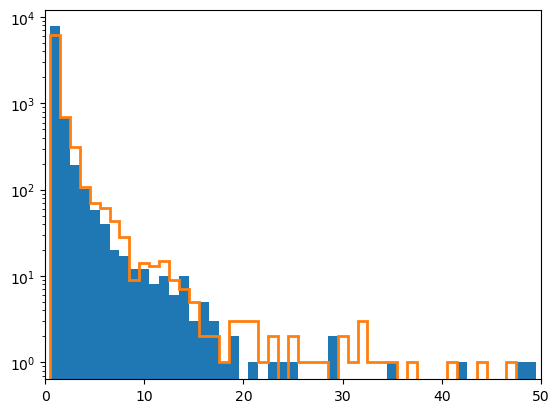

In [12]:
plt.figure()
bins = np.arange(-0.5,300.5,1)
plt.hist(origgroups.g3grpn, bins=bins, label='Original G3 Groups H23')
plt.hist(newgroups.pg3grpn, bins=bins, histtype='step', linewidth=2, label='Probabilistic Groups')
plt.yscale('log')
plt.xlim(0,50)
plt.show()